In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# ✅ Device Setup
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Using Apple MPS')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print('Using CUDA')
else:
    device = torch.device('cpu')
    print('Using CPU')

print(f'Device: {device}')


Using Apple MPS
Device: mps


In [2]:
# Reuse the same HybridCNNViT class definition

class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3, channels=[32, 64, 128]):
        super().__init__()
        layers = []
        prev_channels = in_channels
        for i, out_channels in enumerate(channels):
            layers.extend([
                nn.Conv2d(prev_channels, out_channels, kernel_size=3, 
                          stride=1 if i < len(channels)-1 else 2, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=0.1)
            ])
            if i < len(channels) - 1:
                layers.extend([
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(2)
                ])
            prev_channels = out_channels
        self.cnn = nn.Sequential(*layers)

    def forward(self, x):
        return self.cnn(x)

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=128, embed_dim=256, patch_size=4):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size),
            Rearrange('b e h w -> b (h w) e'),
        )

    def forward(self, x):
        return self.projection(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1, drop_path=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.drop_path = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        return x + self.drop_path(self.mlp(self.norm2(x)))

class HybridCNNViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, num_classes=10,
                 cnn_channels=[32, 64, 128], embed_dim=256, num_heads=8,
                 num_layers=6, mlp_dim=512, dropout=0.1, drop_path_rate=0.1):
        super().__init__()
        self.cnn_features = CNNFeatureExtractor(in_channels, cnn_channels)
        self.patch_embed = PatchEmbedding(cnn_channels[-1], embed_dim, patch_size)
        num_patches = (img_size // (2 ** (len(cnn_channels) - 1)) // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_layers)]
        self.transformer = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout, dpr[i])
            for i in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(embed_dim, num_classes))

    def forward(self, x):
        x = self.cnn_features(x)
        x = self.patch_embed(x)
        B = x.shape[0]
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=B)
        x = torch.cat([cls_tokens, x], dim=1)
        x = self.pos_drop(x + self.pos_embedding[:, :x.size(1)])
        for block in self.transformer:
            x = block(x)
        cls_token_final = self.norm(x)[:, 0]
        return self.head(cls_token_final)


In [3]:
# Load trained model
checkpoint = torch.load('best_hybrid_cnn_vit.pth', map_location=device)
model = HybridCNNViT(num_classes=10)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded pretrained model with validation accuracy: {checkpoint['val_acc']:.2f}%")

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classification head for binary classification
model.head = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(256, 2)
)

model.to(device)
print("✅ Model modified for binary classification and frozen.")


Loaded pretrained model with validation accuracy: 86.84%
✅ Model modified for binary classification and frozen.


In [4]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

# Define transforms (augmentations for training)
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# Load your dataset from folders
train_dataset = datasets.ImageFolder(root='training', transform=train_transform)
val_dataset = datasets.ImageFolder(root='testing', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")


Training samples: 2774, Validation samples: 594
Classes: ['fake', 'real']


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)




Epoch 1/100
------------------------------------------------------------


Training Epoch 1:   0%|          | 0/44 [00:00<?, ?it/s]

Validating: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]



🔓 Unfreezing Transformer + CNN top layers for fine-tuning...
✓ Transformer and CNN layers unfrozen. Fine-tuning at LR = 1e-4
Train Loss: 0.6600 | Train Accuracy: 61.32%
Val Loss: 0.6129 | Val Accuracy: 67.51%
Current LR: 0.000100

Epoch 2/100
------------------------------------------------------------


Validating: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


...

Train Loss: 0.0314 | Train Accuracy: 99.03%
Val Loss: 0.1755 | Val Accuracy: 95.45%
Current LR: 0.000905

Epoch 99/100
------------------------------------------------------------


Validating: 100%|██████████| 10/10 [00:13<00:00,  1.38s/it]


Train Loss: 0.0284 | Train Accuracy: 98.99%
Val Loss: 0.1824 | Val Accuracy: 94.44%
Current LR: 0.000976

Epoch 100/100
------------------------------------------------------------


Validating: 100%|██████████| 10/10 [00:13<00:00,  1.37s/it]


Train Loss: 0.0306 | Train Accuracy: 98.92%
Val Loss: 0.1832 | Val Accuracy: 96.30%
Current LR: 0.001000


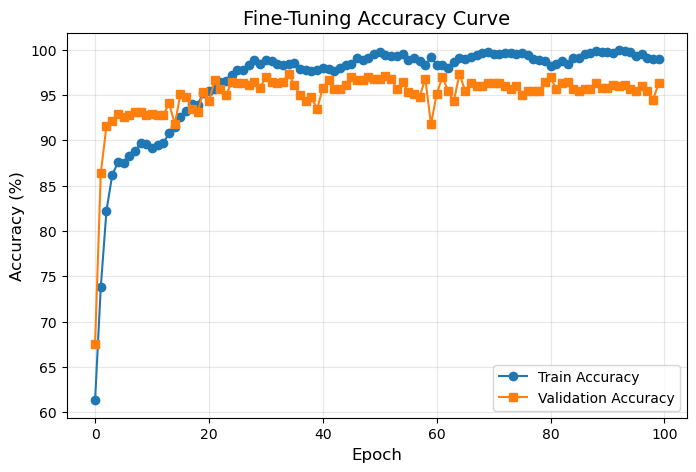

In [6]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR

# -----------------------------------------------
# 🔧 Optimizer and Scheduler Setup
# -----------------------------------------------
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# -----------------------------------------------
# 🧩 Training Loop with Gradual Unfreezing
# -----------------------------------------------
train_accs, val_accs = [], []

for epoch in range(100):
    print(f"\nEpoch {epoch+1}/100")
    print("-" * 60)
    model.train()
    
    running_corrects = 0
    total = 0
    running_loss = 0.0

    # -------------------- Training --------------------
    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Forward and backward in FP32 (safe for MPS)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Accuracy tracking
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels)
        total += labels.size(0)
        running_loss += loss.item()
    
    train_acc = 100 * running_corrects / total
    train_accs.append(train_acc.item())
    avg_train_loss = running_loss / len(train_loader)

    # -------------------- Validation --------------------
    model.eval()
    val_corrects = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels)
            val_total += labels.size(0)
            val_loss += loss.item()

    val_acc = 100 * val_corrects / val_total
    val_accs.append(val_acc.item())

    # Step the LR scheduler
    scheduler.step()

    # -------------------- Fine-tuning Trigger --------------------
    if epoch == 0:
        print("\n🔓 Unfreezing Transformer + CNN top layers for fine-tuning...")
        for name, param in model.named_parameters():
            if any(key in name for key in ["transformer", "cnn_features"]):
                param.requires_grad = True
        # Reduce learning rate to avoid catastrophic forgetting
        for g in optimizer.param_groups:
            g['lr'] = 1e-4
        print("✓ Transformer and CNN layers unfrozen. Fine-tuning at LR = 1e-4")

    # -------------------- Epoch Summary --------------------
    print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss/len(val_loader):.4f} | Val Accuracy: {val_acc:.2f}%")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

# -----------------------------------------------
# 📈 Plot Accuracy Curves
# -----------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Fine-Tuning Accuracy Curve', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()


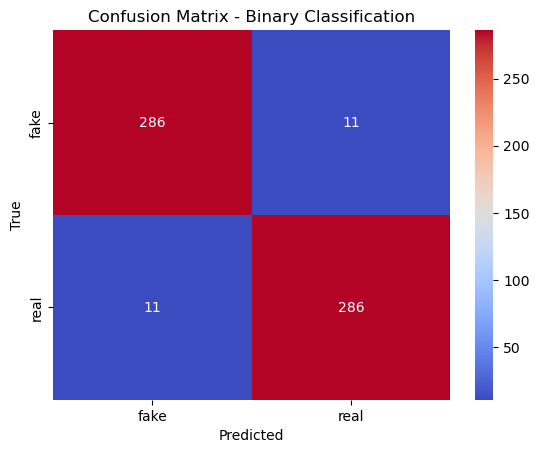


Classification Report:
              precision    recall  f1-score   support

        fake       0.96      0.96      0.96       297
        real       0.96      0.96      0.96       297

    accuracy                           0.96       594
   macro avg       0.96      0.96      0.96       594
weighted avg       0.96      0.96      0.96       594



In [7]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['fake', 'real'], yticklabels=['fake', 'real'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Binary Classification')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['fake', 'real']))


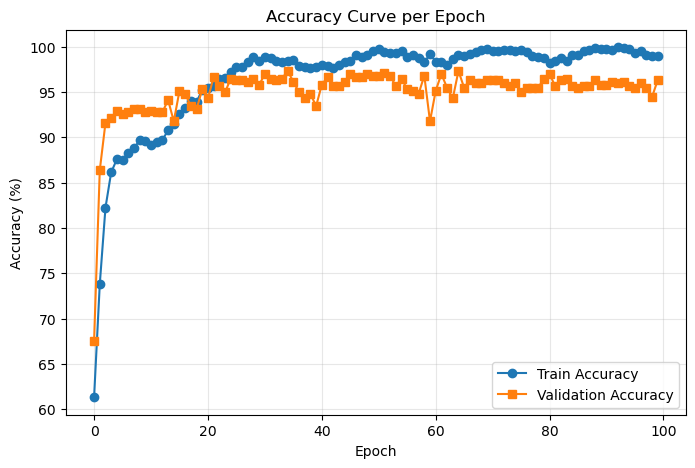

In [8]:
plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve per Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
print("\nTRANSFER LEARNING SUMMARY")
print("="*50)
print("✓ Base Model: Hybrid CNN-ViT (pretrained on CIFAR-10)")
print("✓ Task: Binary Classification (Cats vs Dogs)")
print("✓ Feature Extractor: Frozen CNN + ViT layers")
print("✓ Trainable Head: Single linear layer (256 → 2)")
print("✓ Optimizer: AdamW (LR=1e-3)")
print("✓ Metrics: Accuracy, Confusion Matrix, Classification Report")
print("✓ Hardware: MPS / CUDA supported")
print("="*50)



TRANSFER LEARNING SUMMARY
✓ Base Model: Hybrid CNN-ViT (pretrained on CIFAR-10)
✓ Task: Binary Classification (Cats vs Dogs)
✓ Feature Extractor: Frozen CNN + ViT layers
✓ Trainable Head: Single linear layer (256 → 2)
✓ Optimizer: AdamW (LR=1e-3)
✓ Metrics: Accuracy, Confusion Matrix, Classification Report
✓ Hardware: MPS / CUDA supported


In [10]:
# ============================================================
# Model Complexity Analysis: Parameters and GFLOPs
# ============================================================
# NOTE: No previous code is modified. This is a standalone cell.

import torch
import torch.nn as nn

# --- 1. Total and Trainable Parameter Count ---
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('=' * 55)
print('         MODEL PARAMETER SUMMARY')
print('=' * 55)
print(f'  Total Parameters       : {total_params:>12,}')
print(f'  Trainable Parameters   : {trainable_params:>12,}')
print(f'  Frozen Parameters      : {frozen_params:>12,}')
print('=' * 55)

# --- 2. GFLOPs Estimation via Hook-based MAC counting ---
# Uses manual forward hooks -- no extra library needed.

flop_count = [0]

def conv2d_hook(module, inp, out):
    batch  = inp[0].size(0)
    Cin    = module.in_channels
    Kh, Kw = module.kernel_size
    Oh, Ow = out.shape[2], out.shape[3]
    Cout   = module.out_channels
    groups = module.groups
    macs   = batch * Cout * Oh * Ow * (Cin // groups) * Kh * Kw
    if module.bias is not None:
        macs += batch * Cout * Oh * Ow
    flop_count[0] += 2 * macs

def linear_hook(module, inp, out):
    batch = inp[0].numel() // inp[0].shape[-1]
    macs  = batch * module.in_features * module.out_features
    if module.bias is not None:
        macs += batch * module.out_features
    flop_count[0] += 2 * macs

def layernorm_hook(module, inp, out):
    flop_count[0] += 2 * inp[0].numel()

hooks = []
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        hooks.append(m.register_forward_hook(conv2d_hook))
    elif isinstance(m, nn.Linear):
        hooks.append(m.register_forward_hook(linear_hook))
    elif isinstance(m, nn.LayerNorm):
        hooks.append(m.register_forward_hook(layernorm_hook))

model.eval()
dummy_input = torch.randn(1, 3, 32, 32).to(next(model.parameters()).device)
with torch.no_grad():
    model(dummy_input)

for h in hooks:
    h.remove()

total_flops = flop_count[0]
gflops      = total_flops / 1e9
mflops      = total_flops / 1e6

print()
print('=' * 55)
print('    MODEL COMPUTE COMPLEXITY (single 32x32 image)')
print('=' * 55)
print(f'  Total FLOPs            : {total_flops:>15,}')
print(f'  MFLOPs                 : {mflops:>15.3f}')
print(f'  GFLOPs                 : {gflops:>15.6f}')
print('=' * 55)


         MODEL PARAMETER SUMMARY
  Total Parameters       :    3,829,794
  Trainable Parameters   :    3,303,202
  Frozen Parameters      :      526,592

    MODEL COMPUTE COMPLEXITY (single 32x32 image)
  Total FLOPs            :      65,204,740
  MFLOPs                 :          65.205
  GFLOPs                 :        0.065205
